In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

os.makedirs('../outputs/metrics', exist_ok=True)
os.makedirs('../outputs/plots', exist_ok=True)

# Load cleaned data
df = pd.read_csv('/content/crop_cleaned.csv')
print('Data loaded. Shape:', df.shape)
df.head()

Data loaded. Shape: (110978, 16)


,State,District,Crop,Crop_Year,Season,Area,Production,Yield,Rainfall,Temperature,Season_Encoded,State_Encoded,Crop_Encoded,Log_Yield,Log_Area,Log_Production
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007.0,Kharif,2439.6,3415.0,1.399820,1099.342831,20.792735,0,0,0,0.875394,7.799999,8.136226
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007.0,Rabi,1626.4,2277.0,1.400025,118.911430,27.593758,1,0,0,0.875479,7.394739,7.731053
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008.0,Autumn,4147.0,3060.0,0.737883,243.187611,27.269060,5,0,0,0.552668,8.330382,8.026497
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008.0,Summer,4147.0,2660.0,0.641428,113.934585,32.103427,3,0,0,0.495566,8.330382,7.886457
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009.0,Autumn,4153.0,3120.0,0.751264,145.526618,33.066958,5,0,0,0.560338,8.331827,8.045909


## Step 1: Prepare Features and Target

In [ ]:
# Feature columns to use
feature_cols = ['Crop_Year', 'Log_Area', 'State_Encoded', 'Crop_Encoded', 'Season_Encoded']

# Target — using Log_Yield for better regression performance
target_col = 'Log_Yield'

X = df[feature_cols]
y = df[target_col]

print('Features:', feature_cols)
print('Target:', target_col)
print('X shape:', X.shape)
print('y shape:', y.shape)
print('\nSample of X:')
X.head()

Features: ['Crop_Year', 'Log_Area', 'State_Encoded', 'Crop_Encoded', 'Season_Encoded']
Target: Log_Yield
X shape: (110978, 5)
y shape: (110978,)

Sample of X:


,Crop_Year,Log_Area,State_Encoded,Crop_Encoded,Season_Encoded
0,2007.0,7.799999,0,0,0
1,2007.0,7.394739,0,0,1
2,2008.0,8.330382,0,0,5
3,2008.0,8.330382,0,0,3
4,2009.0,8.331827,0,0,5


## Step 2: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')
print(f'Train size: {len(X_train)/(len(X_train)+len(X_test))*100:.1f}%')

Training samples: 88782
Testing samples:  22196
Train size: 80.0%


## Step 3: Define Helper Functions

In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Train a model and return evaluation metrics."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2  = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    # Cross-validation R2
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_mean = cv_scores.mean()

    print(f'\n--- {name} ---')
    print(f'  R2 Score  : {r2:.4f}')
    print(f'  RMSE      : {rmse:.4f}')
    print(f'  MAE       : {mae:.4f}')
    print(f'  CV R2 Mean: {cv_mean:.4f}')

    return {
        'Model': name,
        'R2 Score': round(r2, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'CV R2': round(cv_mean, 4),
        'y_pred': y_pred,
        'model': model
    }

## Step 4: Train All Models

In [ ]:
results = {}

# Model 1: Linear Regression (baseline)
lr = LinearRegression()
results['Linear Regression'] = evaluate_model(
    'Linear Regression', lr, X_train, X_test, y_train, y_test)

# Model 2: Decision Tree
dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
results['Decision Tree'] = evaluate_model(
    'Decision Tree', dt, X_train, X_test, y_train, y_test)

# Model 3: Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15,
                            min_samples_leaf=3, n_jobs=-1, random_state=42)
results['Random Forest'] = evaluate_model(
    'Random Forest', rf, X_train, X_test, y_train, y_test)

# Model 4: Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=150, max_depth=5,
                                learning_rate=0.1, random_state=42)
results['Gradient Boosting'] = evaluate_model(
    'Gradient Boosting', gb, X_train, X_test, y_train, y_test)

print('\n✅ All models trained successfully!')


--- Linear Regression ---
  R2 Score  : 0.0812
  RMSE      : 0.3838
  MAE       : 0.3066
  CV R2 Mean: 0.0816

--- Decision Tree ---
  R2 Score  : 0.6840
  RMSE      : 0.2250
  MAE       : 0.1584
  CV R2 Mean: 0.6772

--- Random Forest ---
  R2 Score  : 0.8331
  RMSE      : 0.1636
  MAE       : 0.1094
  CV R2 Mean: 0.8262

--- Gradient Boosting ---
  R2 Score  : 0.7388
  RMSE      : 0.2046
  MAE       : 0.1494
  CV R2 Mean: 0.7348

✅ All models trained successfully!


## Step 5: Model Comparison Table

In [ ]:
comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred', 'model']}
    for r in results.values()
])

comparison_df = comparison_df.sort_values('R2 Score', ascending=False)
comparison_df.reset_index(drop=True, inplace=True)
comparison_df.index += 1

print('=== MODEL COMPARISON ===')
print(comparison_df.to_string())

# Save to CSV
comparison_df.to_csv('../outputs/metrics/model_comparison.csv', index=True)
print('\nSaved to outputs/metrics/model_comparison.csv')

=== MODEL COMPARISON ===
               Model  R2 Score    RMSE     MAE   CV R2
1      Random Forest    0.8331  0.1636  0.1094  0.8262
2  Gradient Boosting    0.7388  0.2046  0.1494  0.7348
3      Decision Tree    0.6840  0.2250  0.1584  0.6772
4  Linear Regression    0.0812  0.3838  0.3066  0.0816

Saved to outputs/metrics/model_comparison.csv


## Step 6: Model Comparison Bar Chart

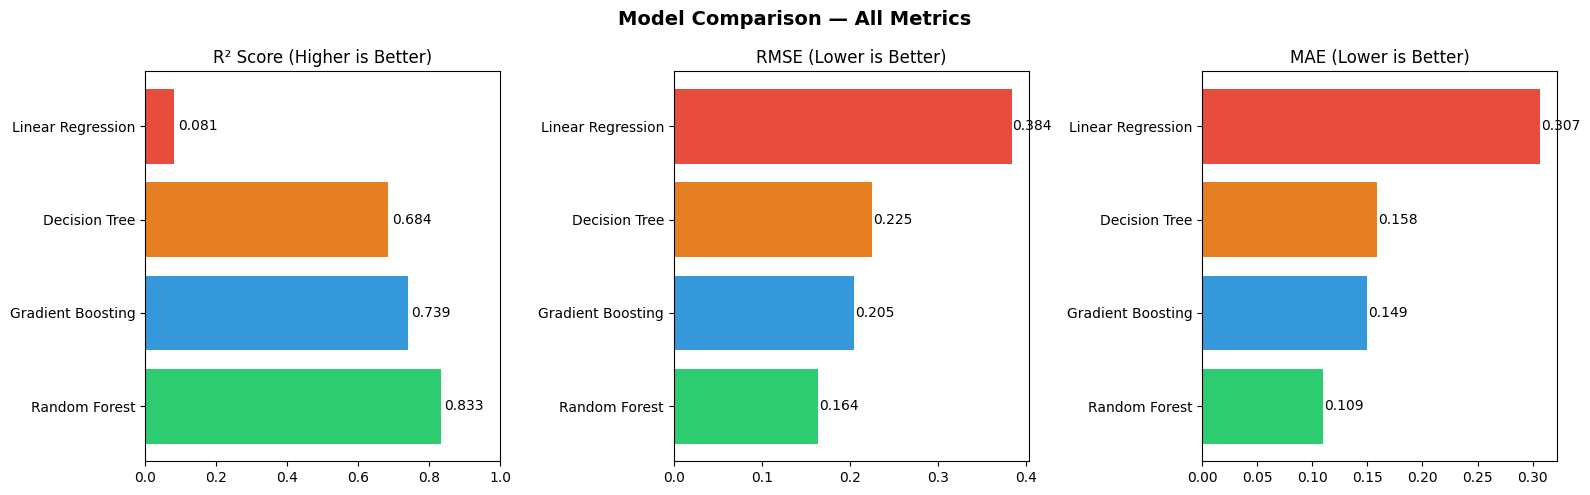

Plot saved: 09_model_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = comparison_df['Model']
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

# R2 Score
axes[0].barh(models, comparison_df['R2 Score'], color=colors)
axes[0].set_title('R² Score (Higher is Better)')
axes[0].set_xlim(0, 1)
for i, v in enumerate(comparison_df['R2 Score']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

# RMSE
axes[1].barh(models, comparison_df['RMSE'], color=colors)
axes[1].set_title('RMSE (Lower is Better)')
for i, v in enumerate(comparison_df['RMSE']):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=10)

# MAE
axes[2].barh(models, comparison_df['MAE'], color=colors)
axes[2].set_title('MAE (Lower is Better)')
for i, v in enumerate(comparison_df['MAE']):
    axes[2].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=10)

plt.suptitle('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 09_model_comparison.png')

## Step 7: Actual vs Predicted Plot (Best Model)

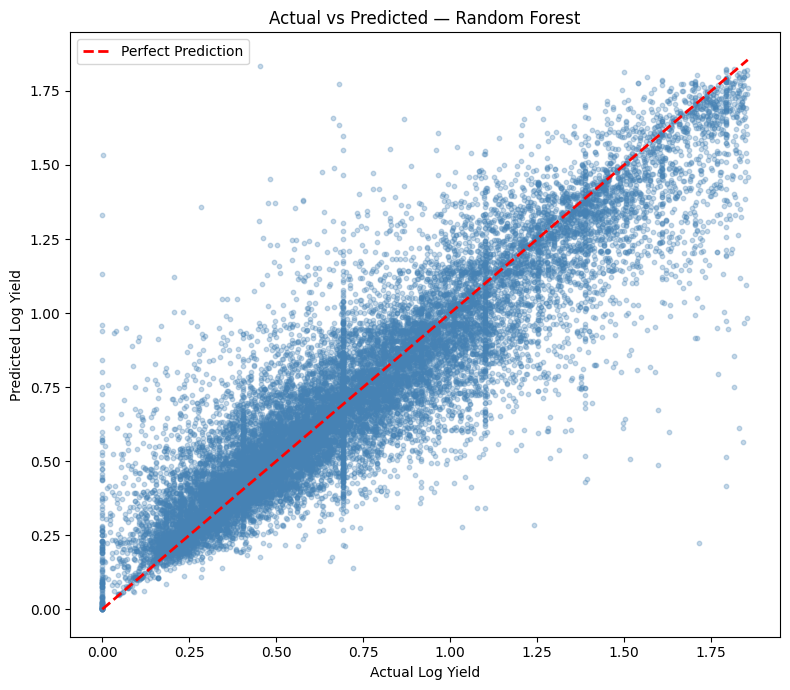

Plot saved: 10_actual_vs_predicted.png  [Best model: Random Forest]


In [ ]:
# Use best model (Random Forest or Gradient Boosting typically wins)
best_model_name = comparison_df.iloc[0]['Model']
best_result = results[best_model_name]
y_pred_best = best_result['y_pred']

plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10, c='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Log Yield')
plt.ylabel('Predicted Log Yield')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/10_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: 10_actual_vs_predicted.png  [Best model: {best_model_name}]')

## Step 8: Feature Importance (Random Forest)

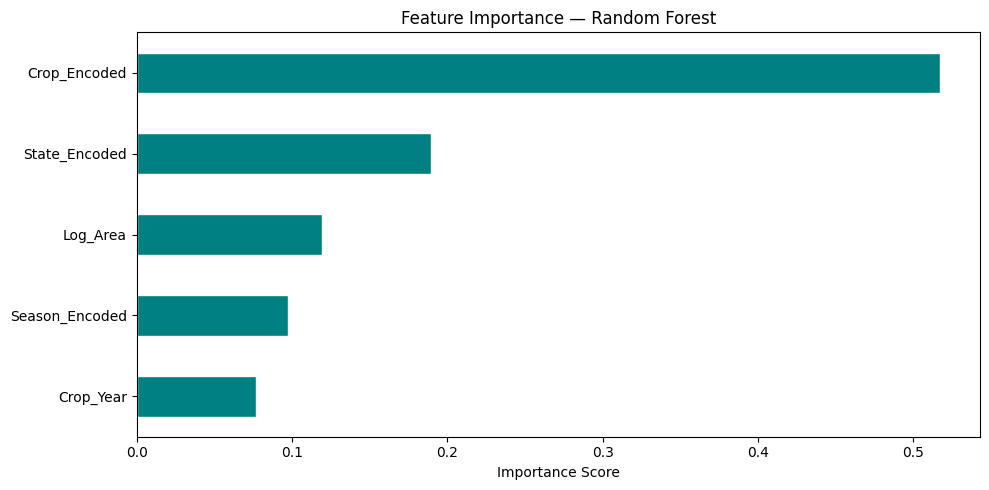

Plot saved: 11_feature_importance.png

Feature Importances:
Crop_Encoded      0.517228
State_Encoded     0.189740
Log_Area          0.119210
Season_Encoded    0.097203
Crop_Year         0.076620
dtype: float64


In [ ]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='teal', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/plots/11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 11_feature_importance.png')

print('\nFeature Importances:')
print(importances.sort_values(ascending=False))

## Step 9: Residual Analysis

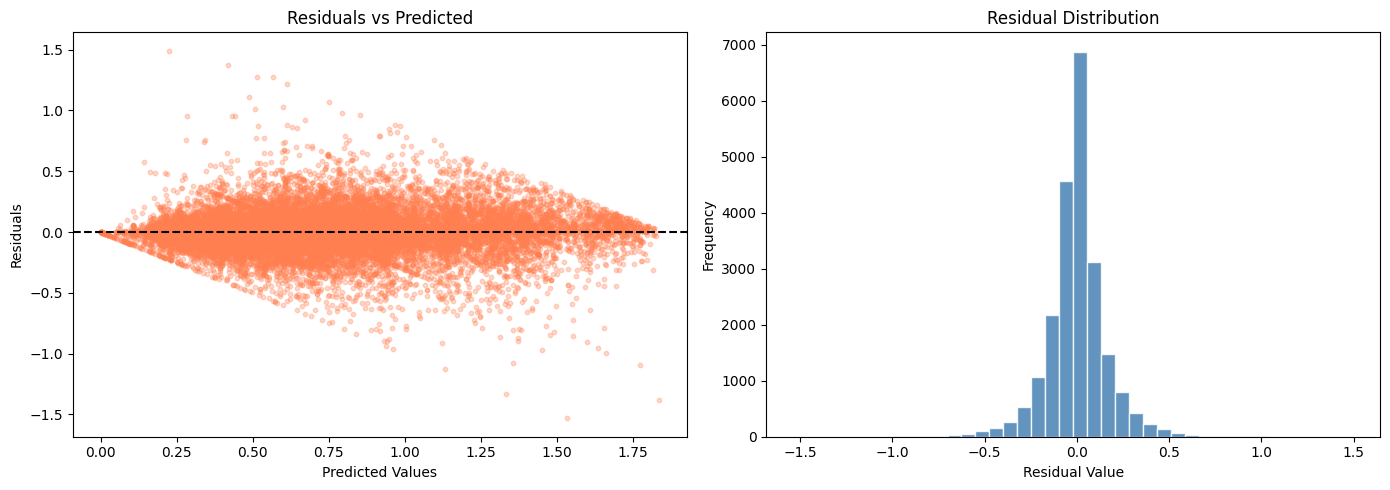

Plot saved: 12_residual_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate residuals
residuals = y_test - y_pred_best

# Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=10, c='coral')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# Residuals histogram
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('../outputs/plots/12_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: 12_residual_analysis.png')